<a href="https://colab.research.google.com/github/renemorenow/MachineLearning2/blob/main/Prog_Basica_Python/Infarto_de_miocardio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### [Abrir en Github](https://github.com/renemorenow/MachineLearning2/blob/main/Prog_Basica_Python/Infarto_de_miocardio.ipynb) ☝


# Grupo 8 Encuentro Final - grupo 4 Canvas:

Integrantes:

Andersson Camilo Ordoñez Ruiz. Cédula de ciudadanía: 1061750759

Miguel Felipe Corredor Montejo. Cédula de ciudadanía: 1098794311

William Rene Moreno Romero. Cédula de ciudadanía: 74329638

## Introducción

Las enfermedades cardíacas son una de las principales causas de mortalidad a nivel mundial. Este análisis explora los factores clave asociados con su aparición, incluyendo edad, sexo, tipo de dolor en el pecho y otros indicadores clínicos. A través del análisis de datos, se identifican patrones que pueden ayudar en la detección temprana y la prevención.


In [48]:
# Importe de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
#Importe de datos
url = 'https://raw.githubusercontent.com/renemorenow/MachineLearning2/refs/heads/main/Prog_Basica_Python/heart.csv'
df = pd.read_csv(url)

## Exploración de datos

In [50]:
#forma del dataframe
df.shape

(303, 14)

In [51]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


El dataframe se compone de 303 filas y 14 columnas. Las filas corresponden a la cantidad de registros de pacientes, las columnas al tipo de variable.

In [52]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

# Convención de variables

La convencion de las variables se presenta a continuación:



**age**: Edad del individuo (numérica).

**sex**: Sexo del individuo (categórica).

    0: Mujer
    1: Hombre

**cp**: Tipo de dolor de pecho (Angina) (categórica).

    1: Angina tipica
    2: Angina atipica
    3: Dolor no anginal
    4: Asintomatico


**trtbps**: Presión arterial en reposo (numérica).

**chol**: Colesterol sérico en mg/dl (numérica).

**fbs**: Nivel de azúcar en sangre en ayunas (categórica).

    1: Nivel de azucar > 120 mg/dl
    0: Nivel de azucar < 120 mg/dl

**restecg**: Resultados del electrocardiograma en reposo (categórica).

    0: Normal
    1: Anormalidad en onda ST-T (inversiones de la onda T y/o elevación o depresión del ST de > 0.05 mV)
    2: Hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes

**thalachh**: Frecuencia cardíaca máxima alcanzada (numérica).

**exng**: Angina inducida por el ejercicio (categórica).

    1 = Si
    0 = no

**oldpeak**: Depresión del segmento ST (numérica).

**slp**: Pendiente del segmento ST (categórica).

    0: Ascendente
    1: Plana (Horizontal)
    2: Descendente

**caa**: Número de vasos principales obstruidos (numérica).

**thall**: Defecto reversible del tálamo (categórica).

    0: Normal
    1: Defecto fijo
    2: Defecto reversible


**output**: Presencia de enfermedad cardíaca (categórica).

    0= Menor probabilidad de ataque cardíaco
    1= Mayor probabilidad de ataque cardíaco

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


El dataframe no contiene valores nulos

## Limpieza:

In [54]:
# ==============================
#  Identificar valores faltantes
# ==============================
print(" Valores faltantes en cada columna:")
print(df.isnull().sum())

 Valores faltantes en cada columna:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


No es necesario imputar datos debido a que no se encontró valores nulos

#Gráficos de distribución de las variables

Las siguientes gráficas corresponden a la distribución de los valores de cada característica del dataframe y corresponden a un gráfico de densidad.

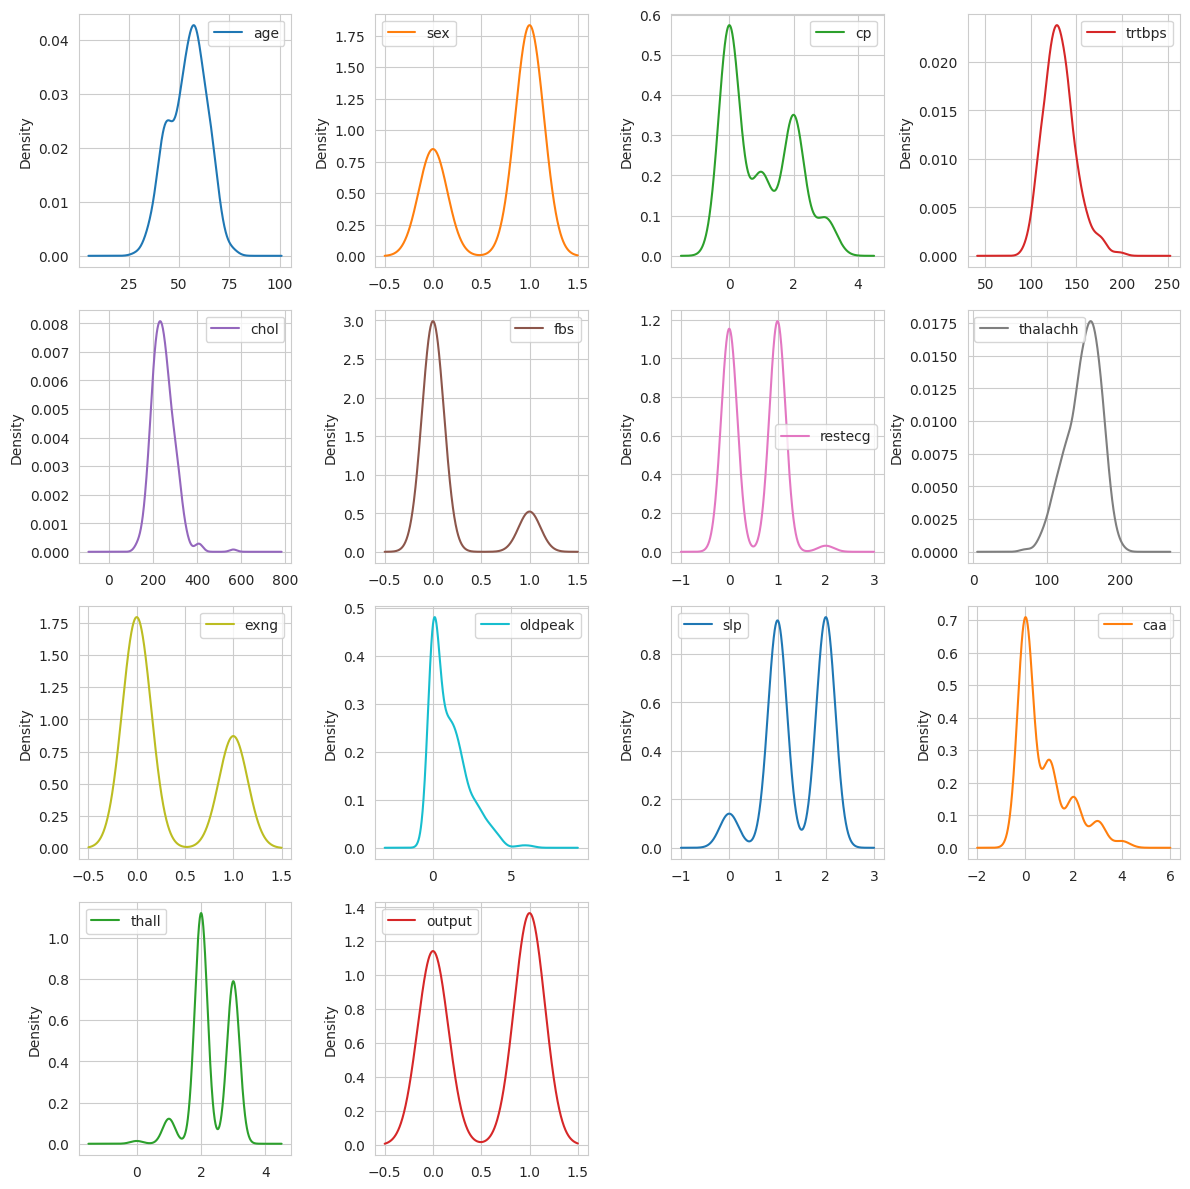

In [55]:
df.plot(kind='density', subplots=True, layout=(4, 4), figsize=(12, 12), sharex=False)
plt.tight_layout()
plt.show()

Teniendo en cuenta que la variable objetivo "output" no presenta diferencias significativas en su distribución, no es necesario realizar balanceo del conjunto de datos.

Se generan histogramas para visualizar la distribución de los valores de cada variable.

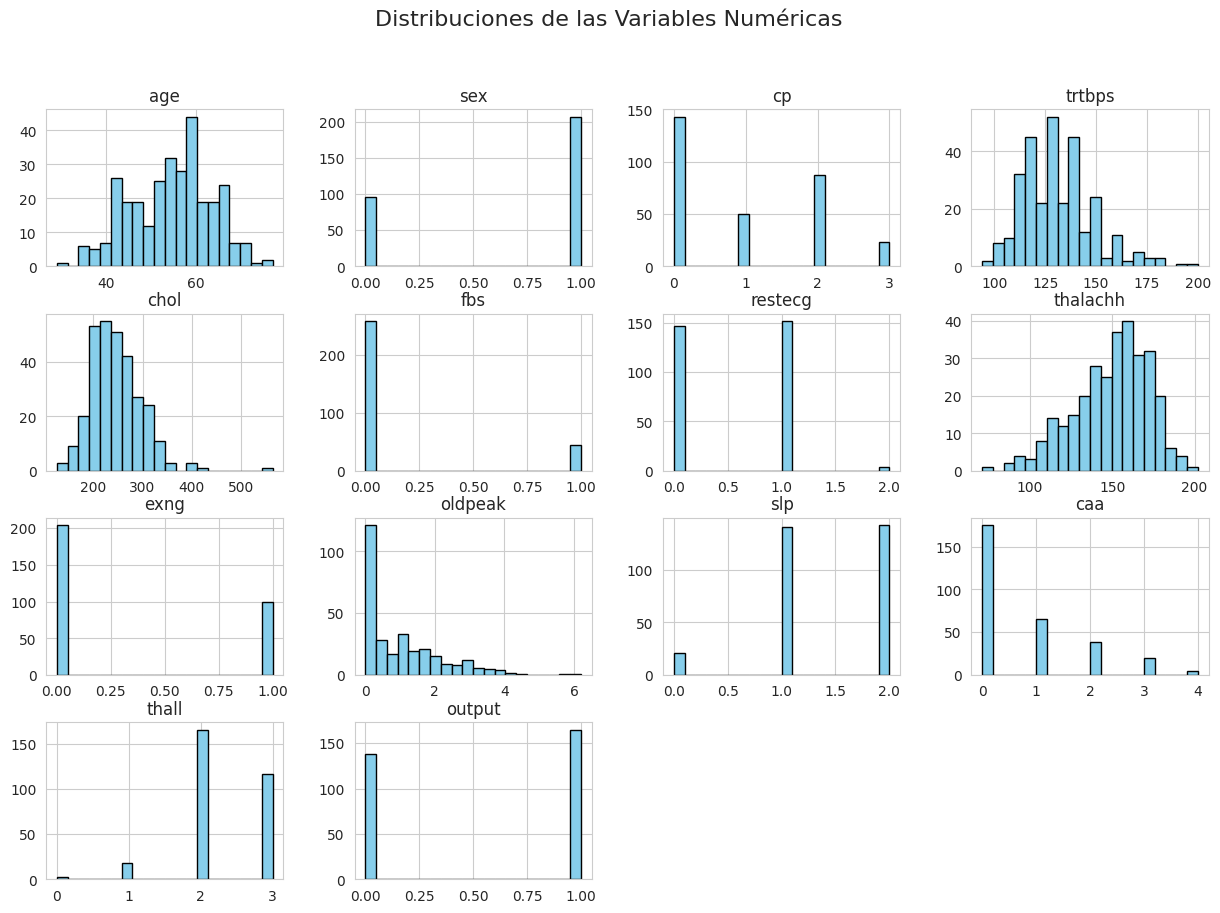

In [56]:
# Distribución de las variables numéricas
df.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribuciones de las Variables Numéricas', fontsize=16)
plt.show()


#Diagrama de cajas:

El siguiente diagrama se emplea para identificar los valores atipicos de cada variable.

,0
0,"Axes(0.1,0.15;0.363636x0.75)"
1,"Axes(0.536364,0.15;0.363636x0.75)"


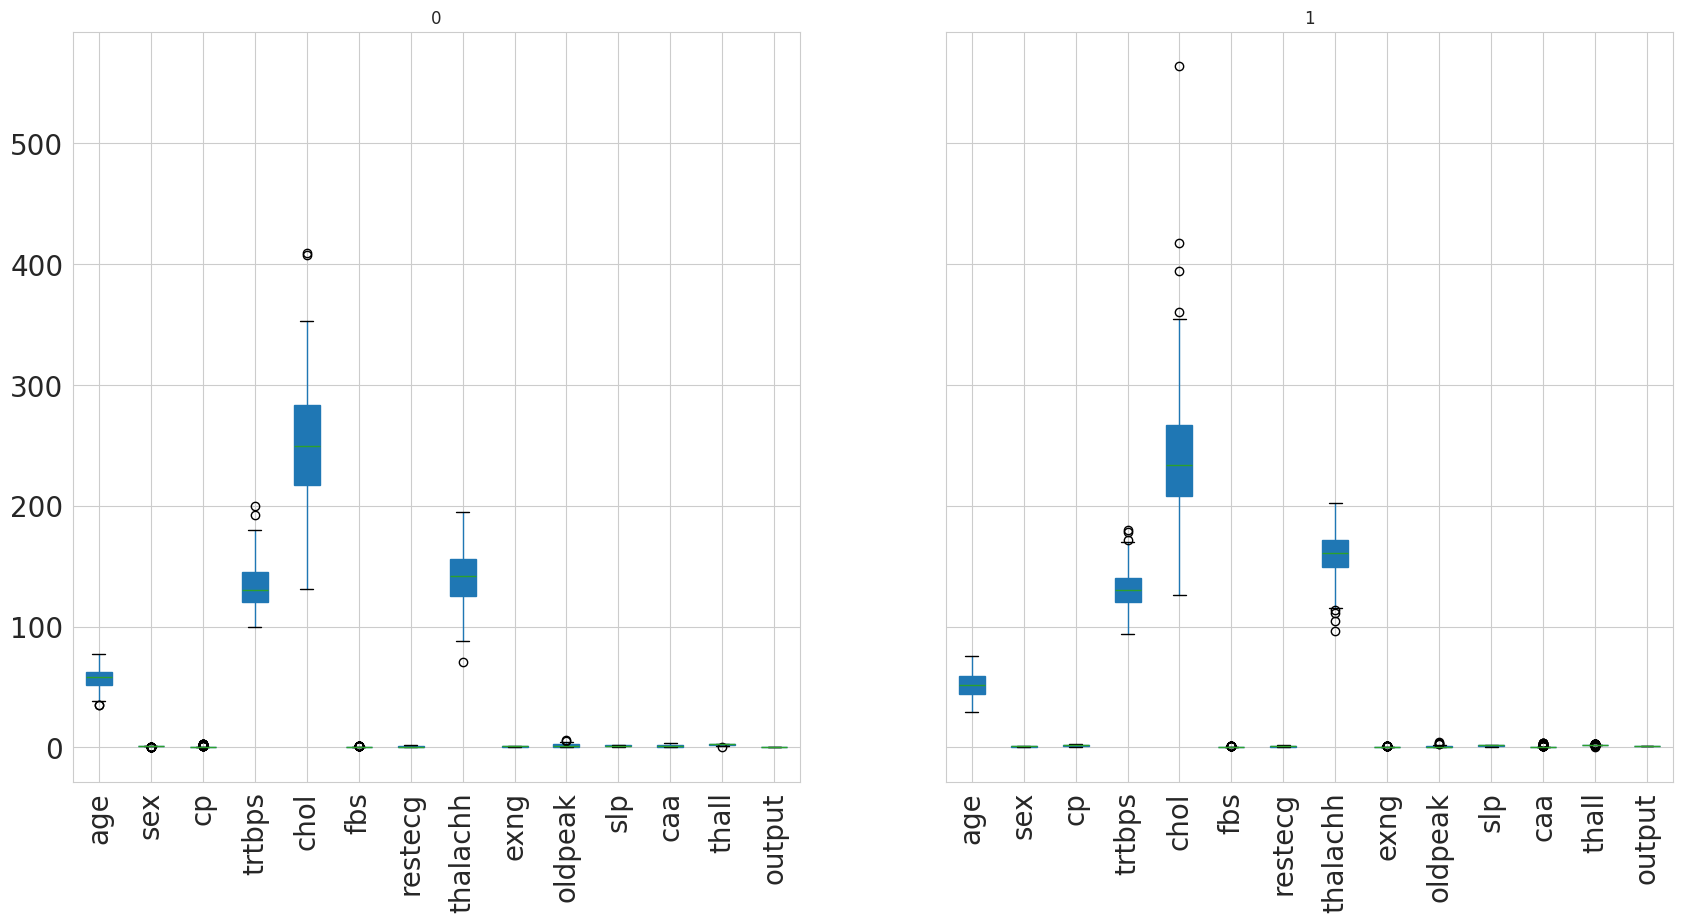

In [57]:
df.groupby('output').boxplot(fontsize=20,rot=90,figsize=(20,10),patch_artist=True)

## Paso 3: Análisis con Pandas y NumPy

### Identificar patrones clave en los datos

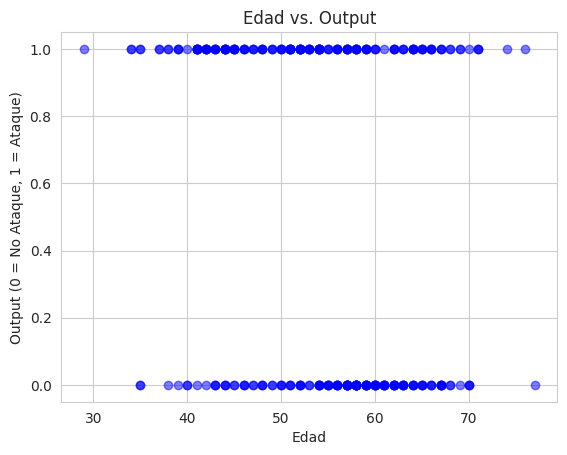

In [58]:
# Variables: "age" y "output" (aquí 'target')
edad = df['age']
output = df['output']


# Crear el gráfico de dispersión
plt.scatter(edad, output, color='blue', alpha=0.5)


# Personalización del gráfico
plt.title("Edad vs. Output")
plt.xlabel("Edad")
plt.ylabel("Output (0 = No Ataque, 1 = Ataque)")


# Mostrar el gráfico
plt.show()

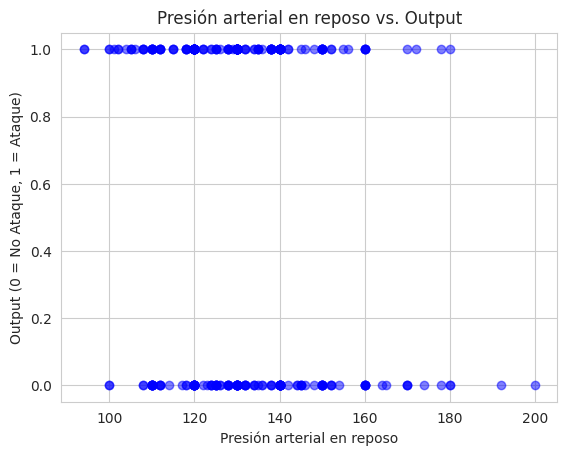

In [59]:
# Variables: "presion" y "output"
presion = df['trtbps']
output = df['output']

# Crear el gráfico de dispersión
plt.scatter(presion, output, color='blue', alpha=0.5)

# Personalización del gráfico
plt.title("Presión arterial en reposo vs. Output")
plt.xlabel("Presión arterial en reposo")
plt.ylabel("Output (0 = No Ataque, 1 = Ataque)")

# Mostrar el gráfico
plt.show()

In [60]:
# Agrupación por Sexo y Presencia de Enfermedad

grouped_sex_target = df.groupby(["sex", "output"]).size().unstack()
print("\nDistribución de la Enfermedad por Sexo:")
print(grouped_sex_target)

# Agrupación por Tipo de Dolor en el Pecho y Presencia de Enfermedad
grouped_cp_target = df.groupby(["cp", "output"]).size().unstack()
print("\nDistribución de la Enfermedad por Tipo de Dolor en el Pecho:")
print(grouped_cp_target)

# Proporción de Enfermedad Cardíaca por Edad
grouped_age_target = df.groupby("age")["output"].mean()
print("\nProporción de Enfermedad Cardíaca por Edad:")
print(grouped_age_target.head())



Distribución de la Enfermedad por Sexo:
output    0   1
sex            
0        24  72
1       114  93

Distribución de la Enfermedad por Tipo de Dolor en el Pecho:
output    0   1
cp             
0       104  39
1         9  41
2        18  69
3         7  16

Proporción de Enfermedad Cardíaca por Edad:
age
29    1.000000
34    1.000000
35    0.500000
37    1.000000
38    0.666667
Name: output, dtype: float64


### •	Cálculo de métricas estadísticas relevantes (media, mediana, percentiles).

In [61]:
df_metricas = df[['age','trtbps', 'chol', 'thalachh']]
metricas = {
    "Media": df_metricas.mean(),
    "Mediana": df_metricas.median(),
    "Percentil 25%": df_metricas.quantile(0.25),
    "Percentil 75%": df_metricas.quantile(0.75)
}

metricas_df = pd.DataFrame(metricas)
metricas_df

,Media,Mediana,Percentil 25%,Percentil 75%
age,54.366337,55.0,47.5,61.0
trtbps,131.623762,130.0,120.0,140.0
chol,246.264026,240.0,211.0,274.5
thalachh,149.646865,153.0,133.5,166.0


### Análisis de tendencias y agrupaciones por categorías:

In [62]:
print("\nAgrupación por presencia de enfermedad cardíaca:")
print(df[['age','trtbps', 'chol', 'thalachh','output']].groupby("output").mean())
print("\nAgrupación por sexo y enfermedad cardíaca:")
print(df[['age','trtbps', 'chol', 'thalachh','sex','output']].groupby(["sex", "output"]).mean())


Agrupación por presencia de enfermedad cardíaca:
              age      trtbps        chol    thalachh
output                                               
0       56.601449  134.398551  251.086957  139.101449
1       52.496970  129.303030  242.230303  158.466667

Agrupación por sexo y enfermedad cardíaca:
                  age      trtbps        chol    thalachh
sex output                                               
0   0       59.041667  146.125000  274.958333  142.416667
    1       54.555556  128.736111  256.750000  154.027778
1   0       56.087719  131.929825  246.061404  138.403509
    1       50.903226  129.741935  230.989247  161.903226


## Paso 4. Visualización de Datos:

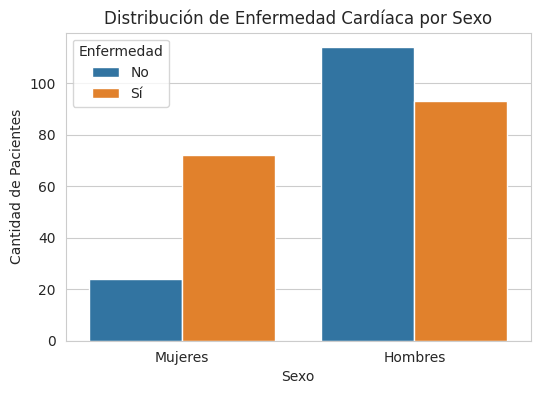

<Figure size 600x400 with 0 Axes>

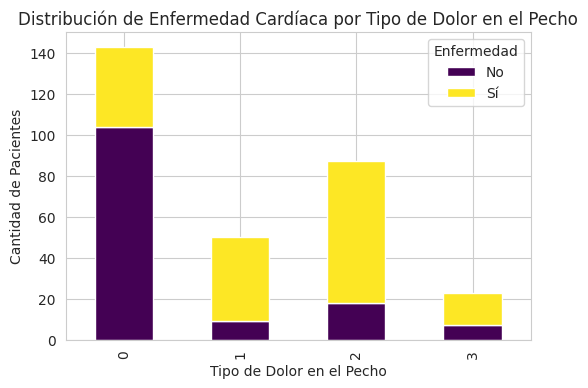

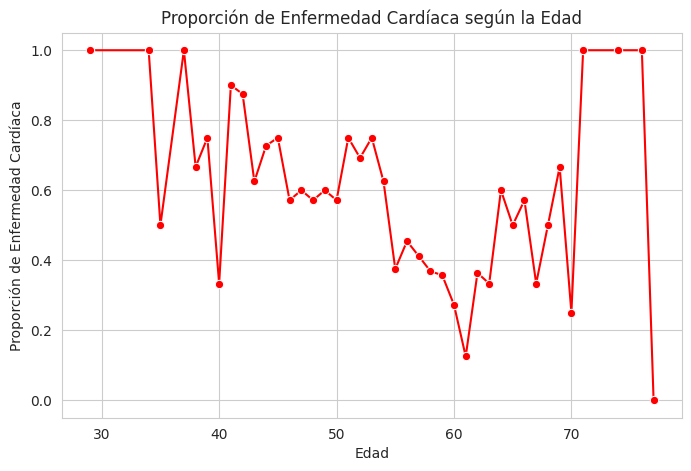

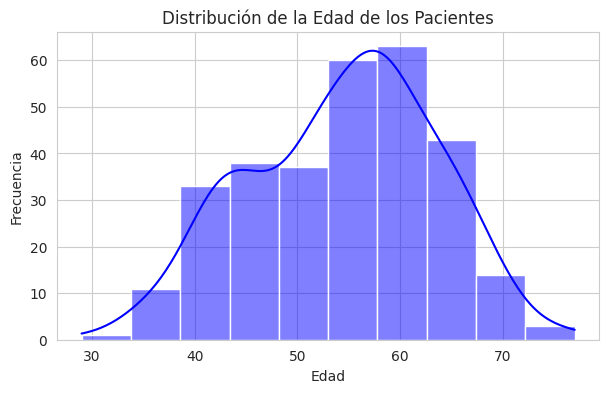

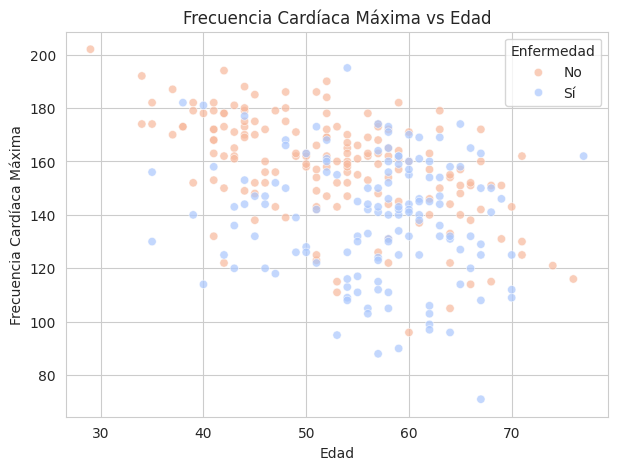

In [63]:
# 4. Visualización de Datos
sns.set_style("whitegrid")

# 4.1 Gráfico de Barras: Distribución de la Enfermedad por Sexo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="output")
plt.xticks(ticks=[0,1], labels=["Mujeres", "Hombres"])
plt.xlabel("Sexo")
plt.ylabel("Cantidad de Pacientes")
plt.title("Distribución de Enfermedad Cardíaca por Sexo")
plt.legend(title="Enfermedad", labels=["No", "Sí"])
plt.show()

# 4.2 Gráfico de Barras Apiladas: Distribución por Tipo de Dolor en el Pecho
plt.figure(figsize=(6,4))
grouped_cp_target.plot(kind="bar", stacked=True, colormap="viridis", figsize=(6,4))
plt.xlabel("Tipo de Dolor en el Pecho")
plt.ylabel("Cantidad de Pacientes")
plt.title("Distribución de Enfermedad Cardíaca por Tipo de Dolor en el Pecho")
plt.legend(title="Enfermedad", labels=["No", "Sí"])
plt.show()

# 4.3 Gráfico de Línea: Relación entre Edad y Enfermedad Cardíaca
plt.figure(figsize=(8,5))
sns.lineplot(x=grouped_age_target.index, y=grouped_age_target.values, marker="o", color="red")
plt.xlabel("Edad")
plt.ylabel("Proporción de Enfermedad Cardíaca")
plt.title("Proporción de Enfermedad Cardíaca según la Edad")
plt.grid(True)
plt.show()

# 4.4 Histograma: Distribución de la Edad de los Pacientes
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=10, kde=True, color="blue")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la Edad de los Pacientes")
plt.show()

# 4.5 Gráfico de Dispersión: Relación entre Frecuencia Cardíaca Máxima y Edad
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="age", y="thalachh", hue="output", alpha=0.7, palette="coolwarm")
plt.xlabel("Edad")
plt.ylabel("Frecuencia Cardíaca Máxima")
plt.title("Frecuencia Cardíaca Máxima vs Edad")
plt.legend(title="Enfermedad", labels=["No", "Sí"])
plt.show()

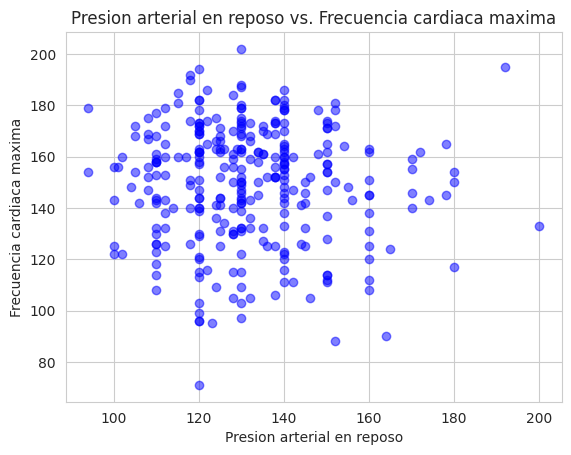

In [64]:
# Variables: "presion" y "output"
Presion = df['trtbps']
FrecMax = df['thalachh']


# Crear el gráfico de dispersión
plt.scatter(Presion, FrecMax, color='blue', alpha=0.5)

# Personalización del gráfico
plt.title("Presion arterial en reposo vs. Frecuencia cardiaca maxima")
plt.xlabel("Presion arterial en reposo")
plt.ylabel("Frecuencia cardiaca maxima")


# Mostrar el gráfico
plt.show()

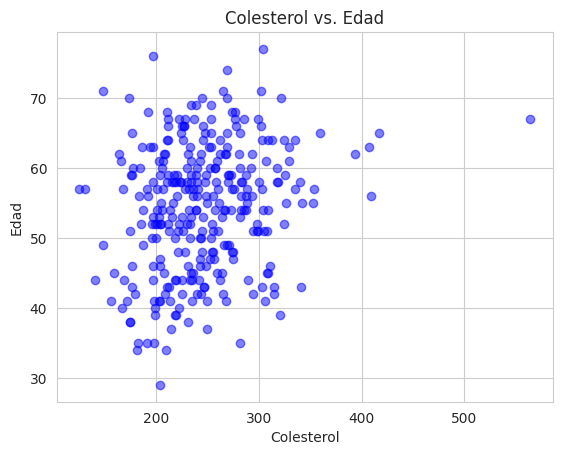

In [65]:
Colesterol = df['chol']
Edad = df['age']


# Crear el gráfico de dispersión
plt.scatter(Colesterol, Edad, color='blue', alpha=0.5)


# Personalización del gráfico
plt.title("Colesterol vs. Edad")
plt.xlabel("Colesterol")
plt.ylabel("Edad")


# Mostrar el gráfico
plt.show()

## Conclusiones

1. Mayor riesgo en hombres: La enfermedad cardíaca es más frecuente en hombres que en mujeres, lo que sugiere la necesidad de controles médicos preventivos en esta población.


2. El tipo de dolor en el pecho es clave: Ciertos tipos de dolor en el pecho están altamente correlacionados con la enfermedad, lo que los convierte en un factor crítico de diagnóstico.


3. La edad influye significativamente: El riesgo aumenta entre los 50 y 60 años, aunque algunos jóvenes también presentan la enfermedad, lo que resalta la importancia de un monitoreo continuo.